
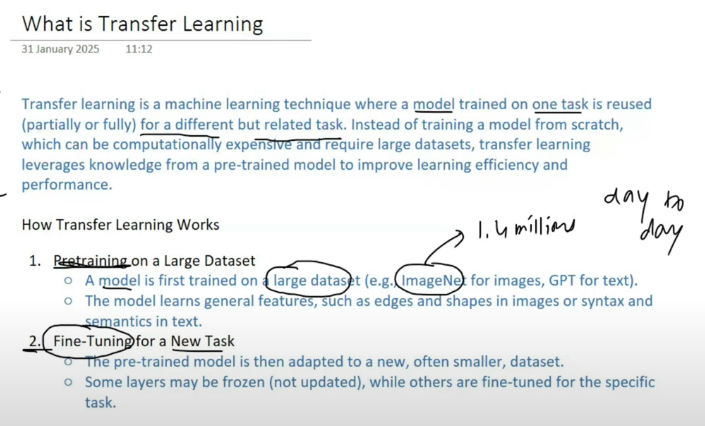

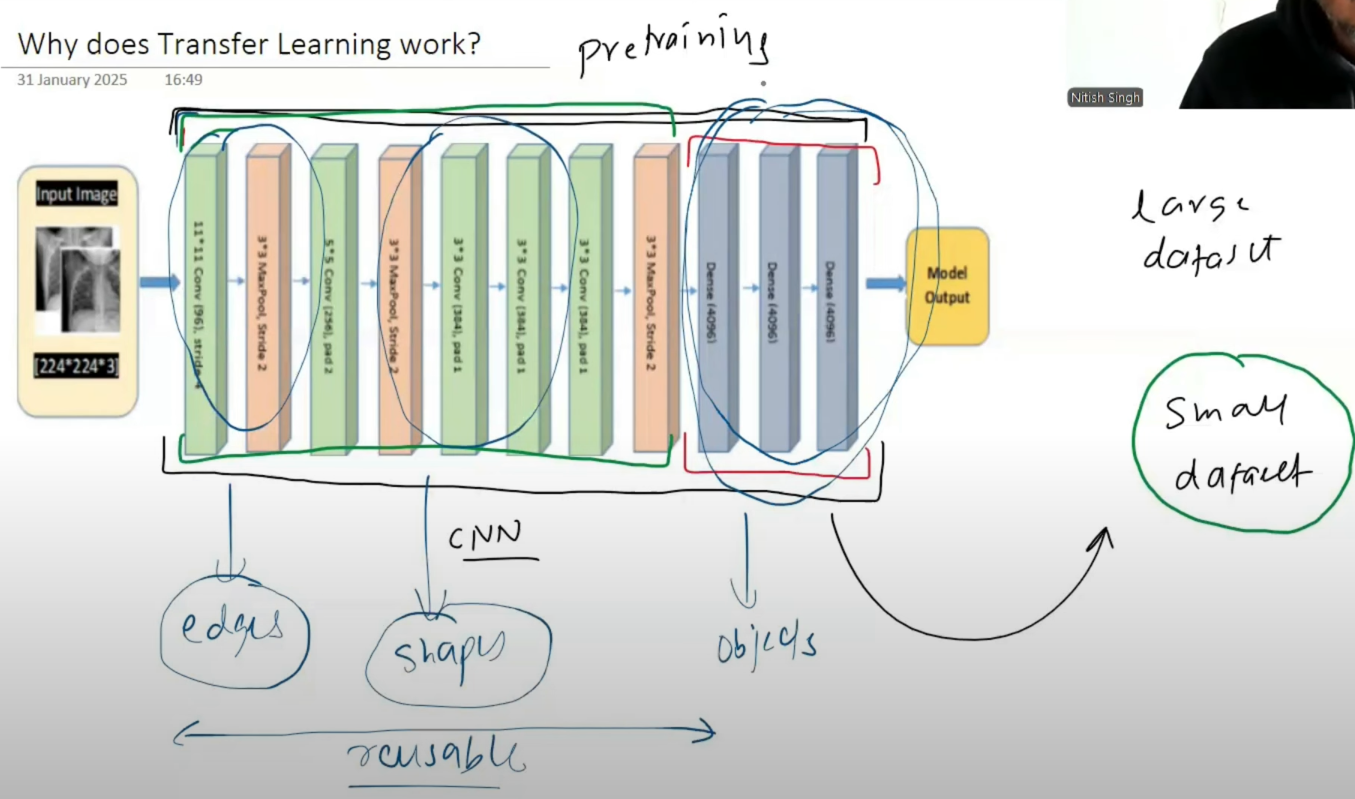

Transfer learning is divided into two parts - In the first part the whole model(i.e. it's every layer) is trained with a large dataset; in the second part the whole convolution part is freezed(i.e. the weights and biases of the convolutional part is freezed) and only the classification head is trained.
Why is the convolutional part is freezed in the first place? - CNN are structured such that, when we are training it with our dataset, the first few convolutions learns to detect the edges(vertical, horizontal, slant edges etc); The middle layers in the convolution layers learns complex shape(like circles, triangles, square); and the final classification layers learns to detect objects like different classes etc. Now as the model architecture is already being trained by large dataset in the first part, they already knows the edges and shapes for many objects (i.e. the weights and biases are already tuned to detect much complex shapes of many many objects), this knowledge can be reused/transferred for doing another task like object detection for small dataset. So that's why in the second part the convolution part is kept frozen and only classifier head is trained for object detection for the smaller dataset.

### **1. Clarification on Transfer Learning Workflow**
- **Pre-trained models**: In practice, transfer learning typically starts with a **pre-trained model** (e.g., ResNet, VGG, etc.) that has already been trained on a large dataset (e.g., ImageNet). You don’t train the "whole model with a large dataset" yourself unless you’re starting from scratch, which is rare due to computational costs. Instead, you **reuse the pre-trained weights**.
- **Two-stage process**:
  - **Stage 1**: Use pre-trained weights (no training required).
  - **Stage 2**: Freeze convolutional layers and train only the classification head on your smaller target dataset.

---

### **2. Why Freeze Convolutional Layers?**
Your reasoning about hierarchical feature learning (edges → shapes → objects) is correct, but here’s a more precise breakdown:

#### **a. General vs. Task-Specific Features**
- **Early layers** learn **generic features** (edges, textures) that are useful across many tasks and datasets.
- **Later layers** learn **task-specific features** (e.g., object parts, full objects) tied to the original dataset (e.g., ImageNet classes like cats, cars, etc.).

Freezing the convolutional base preserves these generic features while allowing the new classification head to adapt to your specific task (e.g., classifying dog breeds or medical images).

#### **b. Data Scarcity**
- If your target dataset is small, training all layers risks **overfitting** (memorizing noise instead of learning general patterns).
- Freezing reduces the number of trainable parameters, making training more stable and efficient.

#### **c. Computational Efficiency**
- Training only the classification head is **faster** and requires fewer resources than retraining the entire model.

---

### **3. When to Unfreeze and Fine-Tune**
Your explanation stops at freezing, but it’s worth noting that **fine-tuning** is a common next step:
- After training the classification head, you can **unfreeze some or all convolutional layers** and train them with a **very small learning rate**.
- This adapts the pre-trained features to your specific task while avoiding catastrophic forgetting of generic features.

---

### **4. Exceptions and Edge Cases**
- **Domain-specific features**: If your target dataset is very different from the original training data (e.g., medical images vs. natural photos), even early layers may need fine-tuning.
- **Very small datasets**: Sometimes people freeze **all layers except the final few** to avoid overfitting.

---

### **Revised Summary**
> Transfer learning leverages pre-trained CNNs (trained on large datasets like ImageNet) by reusing their convolutional layers to extract generic features (edges, textures). These features are broadly useful across tasks, so they’re frozen when adapting the model to a new, smaller dataset. Only the classification head (new task-specific layers) is trained initially to avoid overfitting and computational cost. Later, fine-tuning (unfreezing some convolutional layers) can further improve performance if the dataset allows.

---

### **Key Additions**
- **Hierarchical feature learning**: Early layers → generic features; later layers → task-specific features.
- **Fine-tuning**: Optional step to refine convolutional layers after training the head.
- **Trade-offs**: Freezing balances efficiency, generalization, and data scarcity constraints.

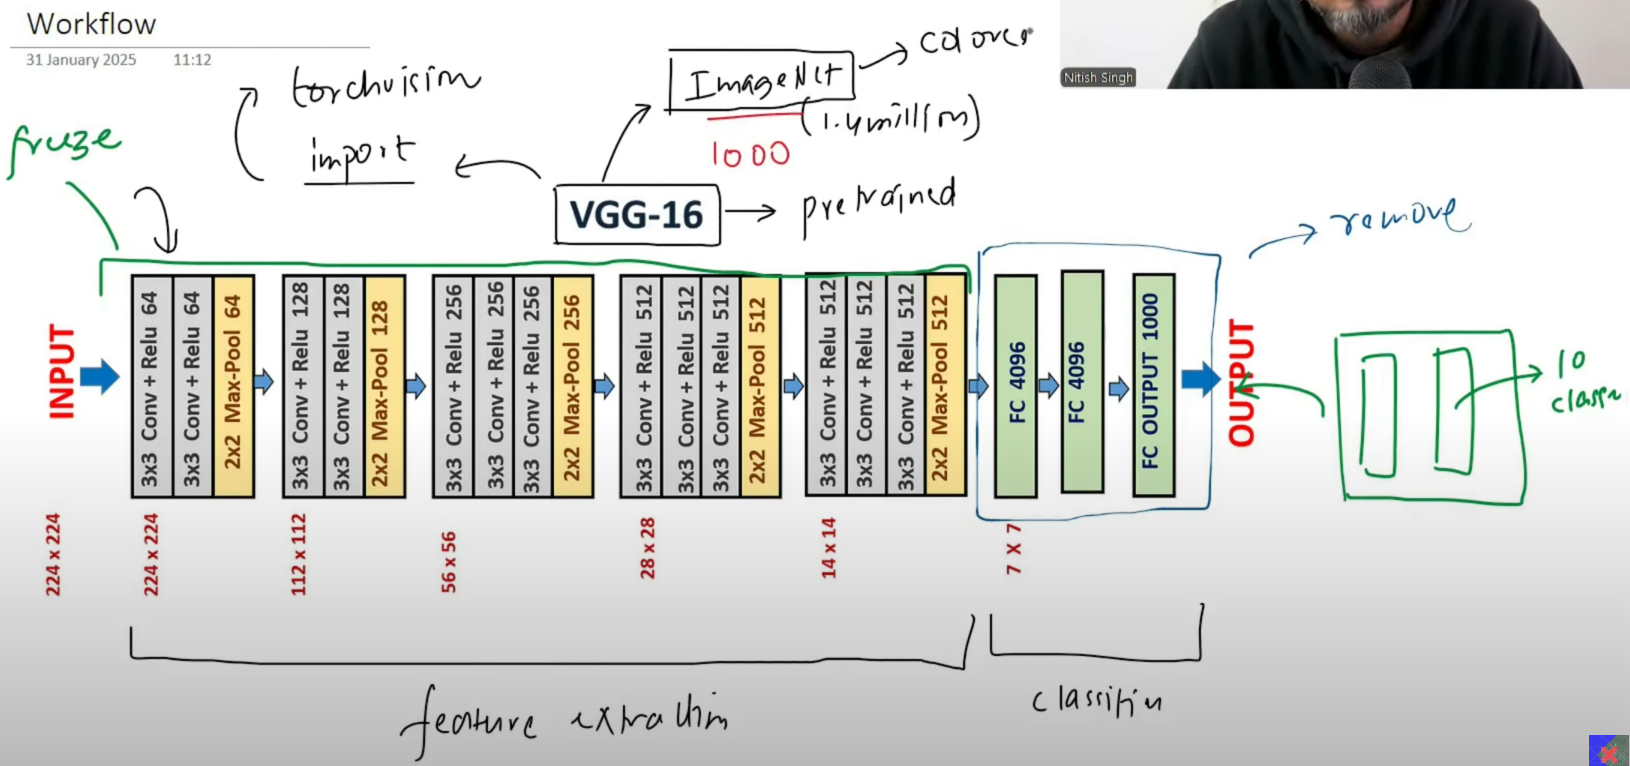

We will use VGG model for our transfer learning task; but we will have to preprocess our data as, vgg model is pretrained with `ImageNet` dataset which us a dataset that consists of coloured images; but our fashion mnist dataset consists of b&w images; so to use vgg for transfer learning we have to convert our single channel dataset with three channeled data; we will copy the data of the single channel in two more channels here.
The steps we have to follow -
1) import the model
2) detach the classifier
3) attach our own classifier head
4) freeze the feature extraction layer(convolutional part)
5) train on our dataset

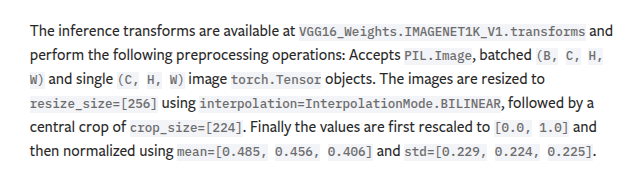
*[VGG16 Documentation](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html#torchvision.models.vgg1)*

So, we have to convert our dataset to the correct image data format so that the VGG model accepts the data. The transformations that we have to apply to our dataset is here follows -
1) Our data is in tabular format, i.e. every image is in the 1D format of shape [784]. We have to reshape it to (28,28), so it converts to a 2d image(matrix).
2) Then we have to change it's datatype to np.uint8 as we have to convert it to a PIL image(as VGG takes only PIL.Image) and PIL wants it's inputs as np.uint8 format. (More about uint8 - Unsigned Integer 8 bits - values for 0 to 255, inclusive both, used to denote pixels in an image)
3) we have to convert the image to a 3D image i.e. have to reshape it from (1,28,28) to a tensor of (3,28,28)
4) convert the tensor to PIL image
5) we have to resize it to (3,256,256)
6) we have to center crop to (3,224,224) (it will be cropping it from the center)
7) we will convert it into a PyTorch tensor and will scale it so that every pixels ranges b/w [0,1]
8) We will normalise the dataset across each channel with  mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]. (See VGG documentation last line) i.e the ImageNet dataset has the Red, Green and Blue channels with mean values of [0.485, 0.456, 0.406] respectively and standard deviation values of [0.229, 0.224, 0.225] respectively. What we will do is we will normalise our RGB channels using this values using the normalization formula $p = \frac{p - \mu}{\sigma}$ i.e. for our small dataset we will normalise the red channel with the formula $ p_{red} = \frac{p_{red}-0.485}{0.229}$ etc.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
df = pd.read_csv("archive/fashion-mnist_test.csv")
X = df.iloc[:,1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# We will delete the portion of scaling  which we were doing previously and will add transformation using pytorch
# we will add the resize, center crop, scaling and normalisation in this transformation itself

from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256), # 5th step of the 8 steps
    transforms.CenterCrop(224), # 6th step of 8 steps
    transforms.ToTensor(), # 7th step of 8 steps
    # ToTensor() converts PIL image format to pytorch tensor
    # as well as it will scale all the pixel values b/w [0,1]
    # and as well as it converts the dimensions back to (C,H,W).
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 8th step of 8 steps
])

In [6]:
from PIL import Image

class CustomDataset(Dataset):
    # the transforms will be passed into the constructor
    def __init__(self, features, labels, transform):
        self.features = features
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        # resize to (28,28) - 1st step of 8steps
        image = self.features[idx].reshape(28,28)

        # change dtype to np.uint8 - 4th step of 8steps
        image = image.astype(np.uint8)

        # change b&w(1D) to color(3D) - 3rd step of 8steps
        image = np.stack([image]*3, axis=-1) # We will copy the information of single channel into 3 channels
        # There is one thing to remember here -> PIL expects it's images in the format (H,W,C)
        # but after the np.stack operation our data's format is (C,H,W) so that's why we do axis=-1 so that
        # while doing np.stack operation the output's shape format becomes (H,W,C)

        # convert array to PIL image - 2nd step of 8 steps
        image = Image.fromarray(image)

        # apply transforms
        image = self.transform(image)
        # NB - one of the step in transform is converting back the PIL image to
        # pytorch tensor using ToTensor(); here ToTensor() method handles
        # the shape conversion of a (H,W,C) dimensional PIL Image back to (C,H,W) dimension
        # so that the data could be accepted by the pytorch torchvision vgg16 class
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

In [7]:
# example of np.stack

arr = np.array([[1,2],[3,4]])
print(arr)
print(arr.shape)

[[1 2]
 [3 4]]
(2, 2)


In [8]:
print(np.stack([arr]*3))
print(np.stack([arr]*3).shape)

[[[1 2]
  [3 4]]

 [[1 2]
  [3 4]]

 [[1 2]
  [3 4]]]
(3, 2, 2)


In [9]:
print(np.stack([arr]*3, axis=-1))
print(np.stack([arr]*3, axis=-1).shape)

[[[1 1 1]
  [2 2 2]]

 [[3 3 3]
  [4 4 4]]]
(2, 2, 3)


In [10]:
train_dataset = CustomDataset(X_train, y_train, transform=custom_transform)
test_dataset = CustomDataset(X_test, y_test, transform=custom_transform)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=1800, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1800, shuffle=False, pin_memory=True)

# Transfer Learning with VGG16

In [12]:
# Now we will start building the model class
# For transfer learning we will fetch the model architecture from torchvision

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True) # It will download the pretrained weights
# use vgg16 = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

/home/starinco/Downloads/youtube/PyTorch/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/starinco/Downloads/youtube/PyTorch/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# from torchvision.models import vgg16, VGG16_Weights
# import torchvision.models as models
#
# vgg16 = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

In [14]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [16]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [17]:
# freezing the features layers

for param in vgg16.features.parameters():
    param.requires_grad = False # Don't require to update weights and biases during backpropagation

In [18]:
# Now we will remove the default classifier head of vgg16 and replace it with our

vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 10)
)

In [19]:
vgg16 = vgg16.to(device)

In [20]:
# generally it is told that if we are using transfer learning then lr should be slow

lr = 0.0001
epochs = 100

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=lr) # The optimizer will update only the classifier's params

In [22]:
# training loop

from tqdm import tqdm

vgg16.train()
for epoch in range(epochs):
    total_epoch_loss = 0
    # Wrap the train_loader with tqdm for progress bar
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for batch_features, batch_labels in batch_iterator:
        # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = vgg16(batch_features)
        # calculate loss
        loss = criterion(outputs, batch_labels)
        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
        # Optionally show current batch loss in tqdm bar
        batch_iterator.set_postfix(loss=loss.item())
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_epoch_loss:.4f}')

Epoch 1/100: 100%|██████████| 16/16 [00:13<00:00,  1.19it/s, loss=0.451]


Epoch: 1, Loss: 0.8452


Epoch 2/100: 100%|██████████| 16/16 [00:12<00:00,  1.24it/s, loss=0.324]


Epoch: 2, Loss: 0.3353


Epoch 3/100: 100%|██████████| 16/16 [00:12<00:00,  1.28it/s, loss=0.189]


...

Epoch: 98, Loss: 0.0000


Epoch 99/100: 100%|██████████| 16/16 [00:12<00:00,  1.25it/s, loss=2.94e-5]


Epoch: 99, Loss: 0.0000


Epoch 100/100: 100%|██████████| 16/16 [00:12<00:00,  1.27it/s, loss=4.07e-5]

Epoch: 100, Loss: 0.0000


In [23]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9085


In [24]:
vgg16.eval()

total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = vgg16(batch_features)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==batch_labels).sum().item()
        total += len(batch_labels)
print(f'Test Accuracy: {correct/total}')

Test Accuracy: 0.9145


In [25]:
vgg16.eval()

total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = vgg16(batch_features)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==batch_labels).sum().item()
        total += batch_labels.shape[0]
print(f'Test Accuracy: {correct/total}')

Test Accuracy: 0.9145


In [26]:
vgg16.eval()

total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = vgg16(batch_features)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==batch_labels).sum().item()
        total += len(batch_features)
print(f'Train Accuracy: {correct/total}')

Train Accuracy: 1.0


# Transfer Learning with resnet 50

In [5]:
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights

resnet50 = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/starinco/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:29<00:00, 3.53MB/s]


In [12]:
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights

resnet50 = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Resnet50 Model Architecture

In [6]:
resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [54]:
for param in resnet50.parameters():
    print(param.shape)

torch.Size([64, 3, 7, 7])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64])
torch.Size([256, 64, 1, 1])
torch.Size([256])
torch.Size([256])
torch.Size([256, 64, 1, 1])
torch.Size([256])
torch.Size([256])
torch.Size([64, 256, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64])
torch.Size([256, 64, 1, 1])
torch.Size([256])
torch.Size([256])
torch.Size([64, 256, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64])
torch.Size([256, 64, 1, 1])
torch.Size([256])
torch.Size([256])
torch.Size([128, 256, 1, 1])
torch.Size([128])
torch.Size([128])
torch.Size([128, 128, 3, 3])
torch.Size([128])
torch.Size([128])
torch.Size([512, 128, 1, 1])
torch.Size([512])
torch.Size([512])
torch.Size([512, 256, 1, 1])
torch.Size([512])
torch.Size([512])
torch.Size([128, 512, 1, 1])
torch.Size([128])
torch.Siz

In [14]:
print(list(resnet50.parameters()))

[Parameter containing:
tensor([[[[-7.4457e-03, -3.1783e-03,  3.7353e-02,  ...,  4.7936e-02,
           -2.0325e-02,  8.8140e-03],
          [-5.7435e-02,  4.4709e-02,  7.7509e-02,  ...,  8.8442e-02,
            2.9346e-02, -5.8331e-02],
          [ 6.8356e-02, -2.7044e-01,  4.0348e-01,  ..., -1.6491e-01,
            2.1868e-01, -7.2909e-02],
          ...,
          [-1.0874e-01,  3.8148e-01, -4.5487e-01,  ...,  6.8366e-01,
           -5.7855e-01,  2.2461e-01],
          [ 2.5698e-02, -1.7703e-01,  6.4375e-01,  ...,  5.2644e-01,
           -4.9317e-02, -6.8082e-02],
          [ 4.5281e-02, -1.3072e-01,  1.7864e-02,  ..., -3.5753e-01,
            1.8976e-01, -2.2302e-02]],

         [[ 8.9197e-03,  4.8768e-03, -1.5356e-02,  ...,  8.6949e-02,
           -6.5541e-02,  1.6895e-02],
          [-3.3543e-02,  3.9067e-02,  8.6565e-02,  ...,  1.1713e-01,
            2.1848e-02, -4.4082e-02],
          [ 5.5285e-02, -2.6424e-01,  4.2687e-01,  ..., -2.3723e-01,
            3.2017e-01, -1.1832e-01

# Continuing Training

In [13]:
# Turning off classifier part

for param in resnet50.parameters():
    param.requires_grad = False

In [14]:
resnet50.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

In [15]:
resnet50 = resnet50.to(device)

lr = 0.0001
epochs = 100

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.fc.parameters(), lr=lr)


In [16]:
# training loop

from tqdm import tqdm

resnet50.train()
for epoch in range(epochs):
    total_epoch_loss = 0
    # Wrap the train_loader with tqdm for progress bar
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for batch_features, batch_labels in batch_iterator:
        # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = resnet50(batch_features)
        # calculate loss
        loss = criterion(outputs, batch_labels)
        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
        # Optionally show current batch loss in tqdm bar
        batch_iterator.set_postfix(loss=loss.item())
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_epoch_loss:.4f}')

Epoch 1/100: 100%|██████████| 5/5 [00:12<00:00,  2.49s/it, loss=2.27]


Epoch: 1, Loss: 2.2865


Epoch 2/100: 100%|██████████| 5/5 [00:10<00:00,  2.01s/it, loss=2.22]


Epoch: 2, Loss: 2.2379


Epoch 3/100: 100%|██████████| 5/5 [00:10<00:00,  2.04s/it, loss=2.13]


...

Epoch: 98, Loss: 0.1939


Epoch 99/100: 100%|██████████| 5/5 [00:10<00:00,  2.07s/it, loss=0.201]


Epoch: 99, Loss: 0.1910


Epoch 100/100: 100%|██████████| 5/5 [00:10<00:00,  2.04s/it, loss=0.177]

Epoch: 100, Loss: 0.1871


In [20]:
# training loop

from tqdm import tqdm

resnet50.train()
for epoch in range(epochs):
    total_epoch_loss = 0
    # Wrap the train_loader with tqdm for progress bar
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for batch_features, batch_labels in batch_iterator:
        # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = resnet50(batch_features)
        # calculate loss
        loss = criterion(outputs, batch_labels)
        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
        # Optionally show current batch loss in tqdm bar
        batch_iterator.set_postfix(loss=loss.item())
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_epoch_loss:.4f}')

Epoch 1/100: 100%|██████████| 5/5 [00:10<00:00,  2.00s/it, loss=0.192]


Epoch: 1, Loss: 0.1869


Epoch 2/100: 100%|██████████| 5/5 [00:09<00:00,  2.00s/it, loss=0.163]


Epoch: 2, Loss: 0.1771


Epoch 3/100: 100%|██████████| 5/5 [00:10<00:00,  2.01s/it, loss=0.175]


...

Epoch: 98, Loss: 0.0377


Epoch 99/100: 100%|██████████| 5/5 [00:10<00:00,  2.00s/it, loss=0.0491]


Epoch: 99, Loss: 0.0395


Epoch 100/100: 100%|██████████| 5/5 [00:10<00:00,  2.03s/it, loss=0.0395]

Epoch: 100, Loss: 0.0376


In [21]:
# training loop
epochs = 50
from tqdm import tqdm

resnet50.train()
for epoch in range(epochs):
    total_epoch_loss = 0
    # Wrap the train_loader with tqdm for progress bar
    batch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for batch_features, batch_labels in batch_iterator:
        # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = resnet50(batch_features)
        # calculate loss
        loss = criterion(outputs, batch_labels)
        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
        # Optionally show current batch loss in tqdm bar
        batch_iterator.set_postfix(loss=loss.item())
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_epoch_loss:.4f}')

Epoch 1/50: 100%|██████████| 5/5 [00:10<00:00,  2.01s/it, loss=0.0415]


Epoch: 1, Loss: 0.0366


Epoch 2/50: 100%|██████████| 5/5 [00:10<00:00,  2.01s/it, loss=0.0329]


Epoch: 2, Loss: 0.0363


Epoch 3/50: 100%|██████████| 5/5 [00:10<00:00,  2.00s/it, loss=0.0409]


...

Epoch: 48, Loss: 0.0199


Epoch 49/50: 100%|██████████| 5/5 [00:09<00:00,  2.00s/it, loss=0.0225]


Epoch: 49, Loss: 0.0193


Epoch 50/50: 100%|██████████| 5/5 [00:10<00:00,  2.03s/it, loss=0.0319]

Epoch: 50, Loss: 0.0208


In [22]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet50(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8185


In [23]:
resnet50.eval()

total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = resnet50(batch_features)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==batch_labels).sum().item()
        total += len(batch_labels)
print(f'Test Accuracy: {correct/total}')

Test Accuracy: 0.826


In [24]:
resnet50.eval()

total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        outputs = resnet50(batch_features)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==batch_labels).sum().item()
        total += len(batch_features)
print(f'Train Accuracy: {correct/total}')

Train Accuracy: 1.0
